# Most Relevant Explanation in Bayesian Networks

## Installs e Imports

In [ ]:
%%capture
!apt-get update
!apt-get install -y graphviz graphviz-dev
!pip install pgmpy pygraphviz

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.utils import get_example_model

from itertools import combinations, product
from IPython.display import Image, display
import matplotlib.pyplot as plt
import pygraphviz as pgv
import pandas as pd
import numpy as np

/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Funções

### GBF

$$GBF(x;e) = \frac{post \cdot (1 - prior)}{prior \cdot (1 - post)}$$

Quantifica o quanto uma evidência $e$ altera as chances (odds) de uma hipótese $x$ ser verdadeira.

Inputs:
- Posterior: $P(x \mid e)$
- Prior: $P(x)$

Output:
- Float que representa a força e direção do suporte que a evidência dá à hipótese

  - GBF > 1: Evidência suporta hipótese, as chances aumentam

  - GBF = 1: Evidência é irrelevante, as chances não mudaram

  - GBF < 1: Evidência contradiz a hipótese, as chances diminuiram

Processamento: Calcula a razão entre as chances a posteriori e a priori



In [ ]:
def gbf(post, prior):
    cond_invalida = (prior <= 0) | (prior >= 1) | (post <= 0)
    res = np.where(cond_invalida, 0.0, (post * (1.0 - prior)) / (prior * (1.0 - post)))
    return np.where(post >= 1.0, float('inf'), res)

### Corolários

#### Corolários 1 e 2

Calcula o GBF de uma configuração de várias portas lógicas simultaneamente.

Inputs:
- spec: um dicionário com a hipótese a ser testada, com as chaves sendo os nomes das variáveis, os valores sendo os estados desejados ({'A': 'defective', 'B': 'ok'})

Lógica:
- Consulta o posterior comparando a probabilidade do evento especificado ocorrer dada uma evidência
- Calcula a probabilidade a priori

Output:
- GBF da combinação específica, float

In [ ]:
def gbf_joint(spec):
    ev_spec = {g: s for g, s in spec.items()}
    q_val = infer_circuito.query(list(spec.keys()), evidence=ev_circ, show_progress=False)
    p_post = q_val.get_value(**spec)
    p_prior = np.prod([PRIORS[g] if s == 'defective' else 1 - PRIORS[g] for g, s in spec.items()])

    return gbf(p_post, p_prior)

### MRE

É uma função que irá calcular o GBF de todas as instanciações parciais de uma rede bayesiana

Inputs:
- inferencia: é a função de inferência do pgmpy
- alvos: lista de variáveis que queremos explicar
- evidencia: o que foi observado
- estados_dict: estados possíveis de cada variável, em dicionário
- priors_dict: probabilidades a priori de cada estado, em dicionário

Lógica:
- solicita a distribuição de probabilidade conjunta dos alvos, dada a evidência, e armazena em q_conjunto
- 3 loops:
  - Loop percorre todos os tamanhos possíveis de explicação (partindo de 1)
  - Loop para todas as combinações de variáveis para esses tamanhos
  - Loop das combinações de estados dessas variáveis
- aplica marginalize() para remover variáveis que não fazem parte de cada instaciação parcial
- a probabilidade a priori é calculada multiplicando as probabilidades iniciais de cada componente da explicação
- a posteriori e priori, a função gbg é chamada e mede a explicação da combinação

Outputs:
- Lista de dicionários em que cada item tem o rótulo explicativo, variáveis, GBF e posteriori

In [ ]:
def calcular_explicacoes_mre(inferencia, alvos, evidencia, estados_dict, priors_dict):
    q_conjunta = inferencia.query(alvos, evidence=evidencia, show_progress=False)
    resultados = []

    for r in range(1, len(alvos) + 1):
        for subset in combinations(alvos, r):
            for combo in product(*[estados_dict[v] for v in subset]):
                spec = dict(zip(subset, combo))

                vars_remover = [v for v in alvos if v not in subset]
                if vars_remover:
                    q_marg = q_conjunta.marginalize(vars_remover, inplace=False)
                    p_post = q_marg.get_value(**spec)
                else:
                    p_post = q_conjunta.get_value(**spec)

                p_prior = np.prod([priors_dict[v][s] for v, s in spec.items()])

                label = ', '.join([f'{v}={s}' for v, s in sorted(spec.items())])

                resultados.append({
                    'label': label,
                    'spec': spec,
                    'gbf': gbf(p_post, p_prior),
                    'p_post': p_post
                })

    return resultados

### K-MRE

Execução do pruning, observando todas as combinações possíveis e descartando as que possuem melhor explicabilidade por outras mais simples ou fortes.

Dominância forte é quando $a$ é subconjunto de $b$ E $GBF(a) >= GBF(b)$, a explicação $a$ é mais concisa e tão boa quando (ou melhor) que $b$.

A dominância fraca é quando $b$ é subconjunto de $a$ E $GBF(a) > GBF(b)$, a explicação $a$ é mais complexa, mas por pouco melhor que a simples $b$.

#### Verificando se um conjunto de variáveis e seus estado é um subconjunto estrito de outra

A função is_subset é responsável por isso.

Inputs:
- Dicionários a e b, são as especificações ({'Lung':'yes'})

Lógica:
- Leva o dicionário em lista de pares (chave, valor)
- Transforma esses pares em conjuntos matemáticos (set(...))
- Operador < verifica se a é subconjunto estrito de b

Outputs:
- Booleana True ou False

In [ ]:
def is_subset(a, b):
    return set(a.items()) < set(b.items())

#### Dominâncias forte e fraca

**Forte:** Remove explicações piores que outras já existentes por serem mais complexas sem oferecer ganho na força da evidência. Para $a$ dominar fortemente $b$:
- is_subset(a['spec'], b['spec']) verifica se $a$ é uma versão simplificada de $b$ (se $b$ tem todas as variáveis de $a$ e ao menos uma adicional)
- a['gbf'] >= b['gbf'] garante que a explicação mais simples ($a$) tem GBF igual ou maior que a mais complexa ($b$).

**Fraca:** Verifica se uma explicação mais variáveis é ligeiramente melhor que uma mais simples.

In [ ]:
def strongly_dominates(a, b):
    return is_subset(a['spec'], b['spec']) and a['gbf'] >= b['gbf']

def weakly_dominates(a, b):
    return is_subset(b['spec'], a['spec']) and a['gbf'] > b['gbf']

#### K-MRE

Seleciona as $K$ melhores explicações que sejam poderosas e concisas simultaneamente.

Inputs:
- todas_explicacoes: lista com todas as combinações possíveis de variáveis e seus estados

Processamento:
- any(...) procura se há pelo menos uma outra explicação melhor que r
- se outra domina fortemente r (mais simples e tão forte quanto) ou fracamente (mais complexa e melhor), r é descartada

Assim somente as explicações que não foram dominadas por ninguém são adicionadas à lista de minimais e ordena-as pelo valor do GBF, retornando as primeiras K posições.

In [ ]:
def kmre(todas_explicacoes, k=3):
    minimais = []
    for r in todas_explicacoes:
        dominada = any(
            strongly_dominates(outra, r) or weakly_dominates(outra, r)
            for outra in todas_explicacoes if outra is not r
        )
        if not dominada:
            minimais.append(r)
    return sorted(minimais, key=lambda x: -x['gbf'])[:k]

### Belief Updating Rate

In [ ]:
def bur(post, prior):
    return np.where(prior > 0, post / prior, 0.0)

## Introdução

### Sistemas Especialistas e MYCIN

Sistemas como MYCIN tinham precisão diagnóstica comparável à de médicos, mas explicavam como o sistema pensou, não como um médico pensaria. O MYCIN combinava CFs com fórmulas que os próprios médicos não entendiam bem. A explicação mostrava os CFs, mas não era óbvio por que aqueles valores foram escolhidos nem como se propagavam. Se o sistema errava, quem respondia? O médico não podia assinar um prontuário dizendo "o MYCIN mandou".

Um sistema especialista é um programa capaz de parear um conjunto de fatos com um conjunto de regras e executar ações com base nas regras que derem match.

Arquitetura de um Sistema Baseado em Conhecimento

- Base de Fatos: é o que observamos, como os sintomas e exames de um paciente
- Base de Regras: é o conhecimento do especialista em IF-THEN, como 600 regras médicas
- Motor de Inferência: é a aplicação das regras aos fatos, como o processo forward ou backward chaining.

### Redes Bayesianas

Uma rede bayesiana pode ser representada por um grafo acíclico direcionado (DAG), onde cada nó é uma variável aleatória e cada aresta é uma dependência probabilística. Todos os nós possuem uma tabela de probabilidade condicional (CPT).

Criando conexões

In [ ]:
modelo = get_example_model('asia')

/tmp/ipykernel_125/1278433823.py:1: FutureWarning: `get_example_model` is deprecated. Please use `pgmpy.example_models.load_model` instead.
  modelo = get_example_model('asia')


In [ ]:
DOENÇAS = ['tub', 'lung', 'bronc']

Visualizando a rede

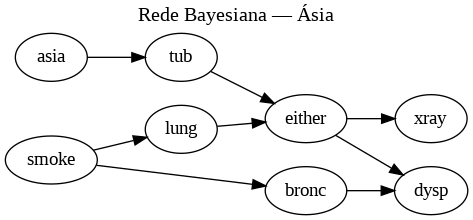

In [ ]:
G = pgv.AGraph(directed=True)

G.add_edges_from(modelo.edges())

G.node_attr['color'] = 'black'
G.node_attr['fontcolor'] = 'black'
G.node_attr['shape'] = 'ellipse'
G.edge_attr['color'] = 'black'

G.graph_attr['label'] = 'Rede Bayesiana — Ásia'
G.graph_attr['labelloc'] = 't'
G.graph_attr['fontsize'] = '15'
G.graph_attr['rankdir'] = 'LR'

G.layout(prog='dot')
G.draw('asia.png')

Image('asia.png')

Simulando 3 cenários:
- 1° caso: Paciente é fumante, não visitou a Ásia, teve raio-x positivo e tem dispneia
- 2° caso: Paciente não é fumante, visitou a Ásia, teve raio-x positivo e tem dispneia.
- 3° caso: Paciente é fumante e tem dispneia.

In [ ]:
ev1 = {'smoke': 'yes',
       'asia': 'no',
       'xray': 'yes',
       'dysp': 'yes'}

ev2 = {'smoke': 'no',
       'asia': 'yes',
       'xray': 'yes',
       'dysp': 'yes'}

ev3 = {'smoke': 'yes',
       'dysp': 'yes'}

A inferência nos permite calcular a distribuição de probabilidades a posteriori de um conjunto de variáveis de consulta, dada uma evidência.

Há diferentes tipos de inferência:
- Inferência Exata:
  - Variable Elimination
  - Message Passing
- Inferência Aproximada
  - MCMC

**Belief Updating**

O Belief Updating calcula a marginal posterior de cada variável-alvo separadamente, somando as probabilidades de todos os outros alvos em uma só métrica (marginalização).



**Variable Elimination**

Calcula essa marginalização, fatorando o conjunto de evidências usando as CPTs da rede. Ao calcular a probabilidade de um alvo, outras variáveis alvo são eliminadas, somando uma sobre a outra.

Podemos quantificar a informação perdida com a tabela de probabilidades conjuntas.

In [ ]:
infer = VariableElimination(modelo)

In [ ]:
ve1_tub = infer.query(['tub'],  evidence=ev1, show_progress=False)
ve1_can = infer.query(['lung'],  evidence=ev1, show_progress=False)
ve1_bro = infer.query(['bronc'],  evidence=ev1, show_progress=False)
q_joint1 = infer.query(DOENÇAS, evidence=ev1, show_progress=False)

ve2_tub = infer.query(['tub'],  evidence=ev2, show_progress=False)
ve2_can = infer.query(['lung'],  evidence=ev2, show_progress=False)
ve2_bro = infer.query(['bronc'],  evidence=ev2, show_progress=False)
q_joint2 = infer.query(DOENÇAS, evidence=ev2, show_progress=False)

ve3_tub = infer.query(['tub'],  evidence=ev3, show_progress=False)
ve3_can = infer.query(['lung'],  evidence=ev3, show_progress=False)
ve3_bro = infer.query(['bronc'],  evidence=ev3, show_progress=False)
q_joint3 = infer.query(DOENÇAS, evidence=ev3, show_progress=False)

**Maximum a Posteriori (MAP)**

Calcula as probabilidades conjuntas diretamente, mas o problema é que ela maximiza para a configuração completa, sendo obrigada a especificar todas as variáveis alvo.

In [ ]:
map1 = infer.map_query(variables=DOENÇAS,
                       evidence=ev1,
                       show_progress=False)

map2 = infer.map_query(variables=DOENÇAS,
                       evidence=ev2,
                       show_progress=False)

map3 = infer.map_query(variables=DOENÇAS,
                       evidence=ev3,
                       show_progress=False)

**Most Probable Explanation**

É um caso especial do MAP, onde todas as variáveis-alvo não são observadas, apenas os nós intermediários e fatores de risco.

In [ ]:
nao_obs_g1 = [n for n in modelo.nodes() if n not in ev1]
nao_obs_g2 = [n for n in modelo.nodes() if n not in ev2]
nao_obs_g3 = [n for n in modelo.nodes() if n not in ev3]

mpe1 = infer.map_query(variables=nao_obs_g1, evidence=ev1, show_progress=False)
mpe2 = infer.map_query(variables=nao_obs_g2, evidence=ev2, show_progress=False)
mpe3 = infer.map_query(variables=nao_obs_g3, evidence=ev3, show_progress=False)

###### 1° caso: Paciente fuma, não visitou a Ásia, teve raio-x positivo e tem dispneia.

In [ ]:
print('Paciente fuma, não foi pra Ásia, tem raio-x positivo e dispneia:')
print(ve1_tub)
print(ve1_can)
print(ve1_bro)
print('Probabilidades conjuntas:')
print(q_joint1)

Paciente fuma, não foi pra Ásia, tem raio-x positivo e dispneia:
+----------+------------+
| tub      |   phi(tub) |
+==========+============+
| tub(yes) |     0.0726 |
+----------+------------+
| tub(no)  |     0.9274 |
+----------+------------+
+-----------+-------------+
| lung      |   phi(lung) |
+===========+=============+
| lung(yes) |      0.7255 |
+-----------+-------------+
| lung(no)  |      0.2745 |
+-----------+-------------+
+------------+--------------+
| bronc      |   phi(bronc) |
+============+==============+
| bronc(yes) |       0.7139 |
+------------+--------------+
| bronc(no)  |       0.2861 |
+------------+--------------+
Probabilidades conjuntas:
+----------+-----------+------------+-----------------------+
| tub      | lung      | bronc      |   phi(tub,lung,bronc) |
+==========+===========+============+=======================+
| tub(yes) | lung(yes) | bronc(yes) |                0.0048 |
+----------+-----------+------------+-----------------------+
| tub(yes) 

O Belief Updating nos mostrou que P(Câncer) = 73% e P(Bronquite) = 71%. A conjunta revelou que P(Câncer=Sim, Bronquite=Sim) = 47,3% + 0,5% = 47,8%.

Há quase 50% de chance de Câncer e Bronquite ocorrerem simultaneamente e Belief não representou essa condição.

In [ ]:
print('Paciente fuma, não foi pra Ásia, tem raio-x positivo e dispneia:')
print(f'MAP: {map1}')
print(f'MPE: {mpe1}')

Paciente fuma, não foi pra Ásia, tem raio-x positivo e dispneia:
MAP: {'bronc': 'yes', 'lung': 'yes', 'tub': 'no'}
MPE: {'bronc': 'yes', 'either': 'yes', 'lung': 'yes', 'tub': 'no'}


MAP: 'Tuberculose = Não' entra na resposta sem acrescentar em nada, pois já foi dado que o paciente fuma e foi na Ásia.

MPE: método independente que maximiza sobre todas as variáveis não observadas — não só as doenças, mas também either, asia e xray. No caso 1, retorna {lung=yes, bronc=yes, either=yes, tub=no}. O nó either=yes é declarado apesar de ser determinado por lung=yes. tub=no e a ausência de visita à Ásia entram sem nenhuma relação com a dispneia do paciente.

O caso mais limpo seria **'Câncer = Sim' e 'Bronquite = Sim'**

Para confirmar se uma doença é relevante na explicação do MAP, colocamos dentro das evidências todas as clínicas do caso + doenças do MAP.

In [ ]:
def check_d_separated(model, start, end, observed):
    active_nodes = model.active_trail_nodes(start, observed=observed)[start]
    return end not in active_nodes

MAP fixou Câncer, Bronquite e Tuberculose, ainda juntamos com nossas evidências.

Para analisarmos Tuberculose, colocamos no observed tudo, exceto ela. Assim descobriremos se ela acrescenta algo, dado que Câncer e Bronquite já explicam a evidência.

###### 2° caso: Paciente não fuma, visitou a Ásia, teve raio-x positivo e tem dispneia.

In [ ]:
print('Paciente não fuma, foi pra Ásia, tem raio-x positivo e dispneia:')
print(ve2_tub)
print(ve2_can)
print(ve2_bro)
print('Probabilidades conjuntas:')
print(q_joint2)

Paciente não fuma, foi pra Ásia, tem raio-x positivo e dispneia:
+----------+------------+
| tub      |   phi(tub) |
+==========+============+
| tub(yes) |     0.6323 |
+----------+------------+
| tub(no)  |     0.3677 |
+----------+------------+
+-----------+-------------+
| lung      |   phi(lung) |
+===========+=============+
| lung(yes) |      0.1265 |
+-----------+-------------+
| lung(no)  |      0.8735 |
+-----------+-------------+
+------------+--------------+
| bronc      |   phi(bronc) |
+============+==============+
| bronc(yes) |       0.4590 |
+------------+--------------+
| bronc(no)  |       0.5410 |
+------------+--------------+
Probabilidades conjuntas:
+----------+-----------+------------+-----------------------+
| tub      | lung      | bronc      |   phi(tub,lung,bronc) |
+==========+===========+============+=======================+
| tub(yes) | lung(yes) | bronc(yes) |                0.0022 |
+----------+-----------+------------+-----------------------+
| tub(yes) 

Underspecification é menos grave aqui, a tuberculose domina. A conjunta acende um alerta de coexistência entre Tuberculose e Bronquite com 22% de probabilidade.

In [ ]:
print('Paciente não fuma, foi pra Ásia, tem raio-x positivo e dispneia:')
print(f'MAP: {map2}')
print(f'MPE: {mpe2}')

Paciente não fuma, foi pra Ásia, tem raio-x positivo e dispneia:
MAP: {'bronc': 'no', 'lung': 'no', 'tub': 'yes'}
MPE: {'bronc': 'no', 'either': 'yes', 'lung': 'no', 'tub': 'yes'}


MAP: declarou 'Bronquite = Não' e 'Câncer = Não', dois estados que não contribuem para explicar Raio-X e dispneia, pois Tuberculose = Sim já explica ambos com Either.

MPE: adicionou também 'Ambos = Sim'. Redundante.

O caso mais limpo seria **'Tuberculose = Sim'**

###### 3° caso: Paciente fuma e tem dispneia

In [ ]:
print('Paciente fuma e tem dispneia:')
print(ve3_tub)
print(ve3_can)
print(ve3_bro)
print('Probabilidades conjuntas:')
print(q_joint3)

Paciente fuma e tem dispneia:
+----------+------------+
| tub      |   phi(tub) |
+==========+============+
| tub(yes) |     0.0154 |
+----------+------------+
| tub(no)  |     0.9846 |
+----------+------------+
+-----------+-------------+
| lung      |   phi(lung) |
+===========+=============+
| lung(yes) |      0.1483 |
+-----------+-------------+
| lung(no)  |      0.8517 |
+-----------+-------------+
+------------+--------------+
| bronc      |   phi(bronc) |
+============+==============+
| bronc(yes) |       0.8802 |
+------------+--------------+
| bronc(no)  |       0.1198 |
+------------+--------------+
Probabilidades conjuntas:
+----------+-----------+------------+-----------------------+
| tub      | lung      | bronc      |   phi(tub,lung,bronc) |
+==========+===========+============+=======================+
| tub(yes) | lung(yes) | bronc(yes) |                0.0010 |
+----------+-----------+------------+-----------------------+
| tub(yes) | lung(yes) | bronc(no)  |         

Bronquite domina disparada e realmente existe na maioria dos casos sozinha.

In [ ]:
print('Paciente fuma e tem dispneia:')
print(f'MAP: {map3}')
print(f'MPE: {mpe3}')

Paciente fuma e tem dispneia:
MAP: {'bronc': 'yes', 'lung': 'no', 'tub': 'no'}
MPE: {'bronc': 'yes', 'lung': 'no', 'asia': 'no', 'xray': 'no', 'either': 'no', 'tub': 'no'}


O conjunto confirmou que 'Bronquite = Sim' e 'Câncer = Não' dominam, mas 'Tuberculose = Nâo' e 'Câncer = Não' estão desnecessariamente aqui.

MPE: adicionou 'Ásia = Não',  'Either = Não' e 'Raio-X = Não'. Foi bem pior, pois não ter ido à Ásia não tem nada a ver com dispneia. Raio-X não foi medido.

O caso mais limpo seria **'Bronquite = Sim'**

## Explanation in Bayesian Networks

### Viagem

O modelo de viagem mostra uma grande falha conceitual do MAP, a sensibilidade ao espaço de estados.

A partir de uma rede bayesiana, vamos modelar as férias do Sr. Smith a partir de três variáveis principais com uma relação de causa e efeito:
- Saúde: Ele pode estar saudável ou não
- Local: Ele pode ficar em casa ou ir fazer uma escalada
- Vivo: Ele sobrevive ou morre. Sua sobrevivência vai depender da saúde dele e de onde ele for.

O objetivo é mostrar como a divisão de estados de uma variável alvo pode influenciar na decisão do MAP. Para isso faremos duas comparações. Primeiramente o Local terá dois estados: Casa ou Escalada. Depois, criaremos novamente a rede e dividiremos a Escalada em Escalada_1, Escalada_2, ..., Escalada_N.

#### 1 estado (Casa e Escalada)

Ditando as arestas

In [ ]:
viagem = DiscreteBayesianNetwork(
    [
        ('Saudável','Local'),
         ('Saudável','Vivo'),
          ('Local','Vivo')

          ]
    )

Construindo o DAG

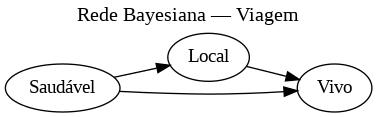

In [ ]:
G_viag = pgv.AGraph(directed=True)

G_viag.add_edges_from(viagem.edges())

G_viag.node_attr['color'] = 'black'
G_viag.node_attr['fontcolor'] = 'black'
G_viag.node_attr['shape'] = 'ellipse'
G_viag.edge_attr['color'] = 'black'

G_viag.graph_attr['label'] = 'Rede Bayesiana — Viagem'
G_viag.graph_attr['labelloc'] = 't'
G_viag.graph_attr['fontsize'] = '15'
G_viag.graph_attr['rankdir'] = 'LR'

G_viag.layout(prog='dot')
G_viag.draw('Viagem.png')

display(Image('Viagem.png'))

Aplicando as CPTs

In [ ]:
cpd_Saudável = TabularCPD('Saudável',
                         2,
                         [[0.2],
                          [0.8]],
                         state_names={'Saudável':['não','sim']})

cpd_Local = TabularCPD('Local',
                          2,
                          [[0.8, 0.1],   # casa
                           [0.2, 0.9]],  # escalada (trilha)
                          evidence=['Saudável'],
                          evidence_card=[2],
                          state_names={'Local':['casa','trilha'],
                                       'Saudável':['não','sim']})

# Adjusting to match paper results: high mortality if unhealthy on a hike
cpd_Vivo = TabularCPD('Vivo',
                       2,
                       [[0.10, 0.90, 0.01, 0.01], # não (morreu)
                        [0.90, 0.10, 0.99, 0.99]],# sim (viveu)
                       evidence=['Saudável','Local'],
                       evidence_card=[2,2],
                       state_names={'Vivo':['não','sim'],
                                    'Saudável':['não','sim'],
                                    'Local':['casa','trilha']})

viagem.add_cpds(cpd_Saudável, cpd_Local, cpd_Vivo)

Inferência com VariableElimination

In [ ]:
infer_viagem = VariableElimination(viagem)

Alvos: Saudável e Local. A partir do estado vital do Sr. Smith., queremos entender como a saúde e o local se comportam.

In [ ]:
ALVO_V  = ['Saudável','Local']

Dado que o Sr. Smith. sobreviveu, qual a combinação exata de eventos que tem a maior probabilidade conjunta de ter acontecido?

In [ ]:
map_vivo_1estado = infer_viagem.map_query(variables=ALVO_V,
                                      evidence={'Vivo':'sim'},
                                          show_progress=False)
print('Dado: Vivo = sim')
print('MAP modelo 1-estado:', map_vivo_1estado)

Dado: Vivo = sim
MAP modelo 1-estado: {'Saudável': 'sim', 'Local': 'trilha'}


A melhor explicação matemática é que ele está saudável e foi fazer a escalada.

Agora vamos fazer o contrário, dados que ele morreu, qual é a combinação exata de eventos com a maior probabilidade conjunta de ter acontecido?

In [ ]:
map_morto_1estado = infer_viagem.map_query(variables=ALVO_V,
                                       evidence={'Vivo':'não'},
                                           show_progress=False)
print('Dado: Vivo = não')
print('MAP modelo 1-estado:', map_morto_1estado)

Dado: Vivo = não
MAP modelo 1-estado: {'Saudável': 'não', 'Local': 'trilha'}


Dado que ele morreu, muito provavelmente ele fez a escalada sem estar saudável.

#### Multi-estado: Casa + Escalada_1, Escalada_2, ..., Escalada_N

Agora, dividiremos a escalada em várias trilhas (estados), fragmentando também as probabilidades antes concentrada apenas em Escalada.

Se a explicação do sistema mudar só pelo detalhamento maior de uma variável, o sistema perde sua credibilidade.

Usamos N=3 neste capítulo para manter a visualização legível. No Capítulo 5, recriamos com N=100 como no paper original.

In [ ]:
N = 3  # Usamos N=3 aqui para fins didáticos — o paper usa N=100.
       # O Cap 5 recria com N=100 para reproduzir os numeros exatos.
loc_states = ['casa'] + [f'escalada_{i+1}' for i in range(N)]

viagem_multi = DiscreteBayesianNetwork([
    ('Saudável','Local'),
     ('Saudável','Vivo'),
      ('Local','Vivo')
])

cpd_saudável2 = TabularCPD('Saudável',
                    2,
                    [[0.2],
                     [0.8]],
                    state_names={'Saudável':['não','sim']})

p_casa_nao=0.8; p_home_yes=0.1
p_escalada_nao=(1-p_casa_nao)/N; p_hike_yes=(1-p_home_yes)/N
loc_vals = [[p_casa_nao, p_home_yes]] + [[p_escalada_nao, p_hike_yes]]*N

cpd_local2 = TabularCPD('Local',
                        N+1,
                        loc_vals,
                        evidence=['Saudável'],
                        evidence_card=[2],
                        state_names={'Local':loc_states,
                                     'Saudável':['não','sim']})

vivo_vals_nao  = [0.10, 0.01] + [0.90, 0.99]*N  # morreu
vivo_vals_sim = [0.90, 0.99] + [0.10, 0.01]*N  # sobreviveu

cols_nao  = []
cols_sim = []
for loc in loc_states:
    if loc == 'home':
        cols_nao.append(0.10);  cols_sim.append(0.90)
    else:
        cols_nao.append(0.90);  cols_sim.append(0.10)

p_vivo_nao  = cols_nao  + cols_nao   # morreu dado (H=não,L) e (H=sim,L)
p_morto_linha  = cols_nao + [0.01]*len(loc_states)
p_vivo_linha = [1-v for v in p_morto_linha]

cpd_vivo2 = TabularCPD('Vivo',
                       2,
                       [p_morto_linha, p_vivo_linha],
                       evidence=['Saudável','Local'],
                       evidence_card=[2, N+1],
                       state_names={'Vivo':['não','sim'],
                                    'Saudável':['não','sim'],
                                    'Local':loc_states})

viagem_multi.add_cpds(cpd_saudável2, cpd_local2, cpd_vivo2)
assert viagem_multi.check_model()

In [ ]:
infer_vm = VariableElimination(viagem_multi)

In [ ]:
map_morto_multi = infer_vm.map_query(
                        variables=['Saudável','Local'],
                        evidence={'Vivo':'não'},
                        show_progress=False
)

Vamos fazer a mesma pergunta de antes: Dado que ele sobreviveu, o que pode ter acontecido com maior probabilidade?

In [ ]:
map_vivo_multi = infer_vm.map_query(variables=ALVO_V,
                                       evidence={'Vivo':'sim'},
                                           show_progress=False)
print('Dado: Vivo = sim')
print('MAP modelo multi-estado:', map_vivo_multi)

Dado: Vivo = sim
MAP modelo multi-estado: {'Local': 'escalada_1', 'Saudável': 'sim'}


Ele fez a escalada_1 saudável.

Agora vamos para o cenário extremo, Sr. Smith. morreu. O que houve com ele?

In [ ]:
map_morto_multi = infer_vm.map_query(variables=ALVO_V,
                                       evidence={'Vivo':'não'},
                                           show_progress=False)
print('Dado: Vivo = não')
print('MAP modelo multi-estado:', map_morto_multi)

Dado: Vivo = não
MAP modelo multi-estado: {'Saudável': 'não', 'Local': 'casa'}


Ele morreu em casa e não estava saudável

O MAP tem sensibilidade ao espaço de estados. A explicação muda completamente de forma ilógica ao fragmentarmos as opções de uma variável.

### Circuito Elétrico

Este exemplo traz um problema, a **superespecificação**. A matemática do MAP obriga-o devolver o estado mais provável de todas as variáveis solicitadas para análise.

Existem 4 gates (A, B, C, D), cada um com apenas dois estados possíveis:
- ok
- defeituoso

A energia entra pelo nó Input e ramifica-se pelos portões até chegar ao TotalOutput, dependendo do estado de cada portão.

Iremos observar uma evidência bem específica: Dado que a corrente entrou (Input = corrente) e saiu (TotalOutput = corrente), qual é a configuração mais provável de falhas nos portões internos?
- corrente: Há energia fluindo e passando pelo ponto
- sem corrente: fluxo energético foi interrompido

In [ ]:
circuito = DiscreteBayesianNetwork([
    ('Input', 'OutA'), ('A', 'OutA'),
    ('Input', 'OutB'), ('B', 'OutB'),
    ('OutB',  'OutC'), ('C', 'OutC'),
    ('OutB',  'OutD'), ('D', 'OutD'),
    ('OutA',  'TotalOutput'),
    ('OutC',  'TotalOutput'),
    ('OutD',  'TotalOutput'),
])

Contextualização das variáveis:
- A fonte alimenta a energia do sistema
- Os nós A, B, C, D podem funcionar ou não
- A energia do input se divide em OutA e OutB. Para o OutA ter corrente, input precisa ter corrente e A estar ok. O mesmo para B.
- A energia que entra em C e D depende de B.
- A energia que chega ao final conseguiu completar o trajeto por qualquer um dos caminhos (OutA, OutC ou OutD).

Representando visualmente a rede bayesiana do circuito

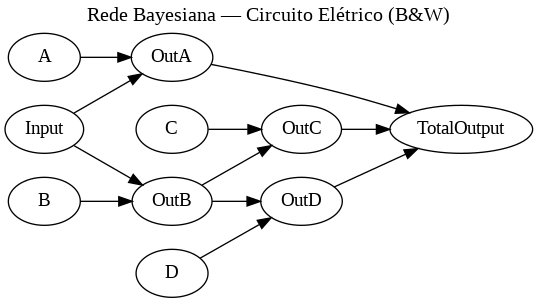

In [ ]:
G_circ = pgv.AGraph(directed=True)

G_circ.add_edges_from(circuito.edges())

G_circ.node_attr['color'] = 'black'
G_circ.node_attr['fontcolor'] = 'black'
G_circ.node_attr['shape'] = 'ellipse'
G_circ.edge_attr['color'] = 'black'

G_circ.graph_attr['label'] = 'Rede Bayesiana — Circuito Elétrico (B&W)'
G_circ.graph_attr['labelloc'] = 't'
G_circ.graph_attr['fontsize'] = '15'
G_circ.graph_attr['rankdir'] = 'LR'

G_circ.layout(prog='dot')
G_circ.draw('circuito_bw.png')

display(Image('circuito_bw.png'))

Cada portão terá uma chance diferente de vir com defeito de fábrica (priors):
- A: 1.6%
- B: 10%
- C: 15%
- D: 10%


In [ ]:
S = ['ok', 'defective']
F = ['noCurr', 'current']

cpd_A = TabularCPD('A',
                   2, #2 estados: com ou sem defeito
                   [[1-0.016],#sem defeito
                    [0.016]],#com defeito
                   state_names={'A': S})

cpd_B = TabularCPD('B',
                   2, #2 estados: com ou sem defeito
                   [[1-0.1],#sem defeito
                    [0.1]],#com defeito
                   state_names={'B': S})

cpd_C = TabularCPD('C',
                   2, #2 estados: com ou sem defeito
                   [[1-0.15],#sem defeito
                    [0.15]],#com defeito
                   state_names={'C': S})

cpd_D = TabularCPD('D',
                   2, #2 estados: com ou sem defeito
                   [[1-0.1],#sem defeito
                    [0.1]],#com defeito
                   state_names={'D': S})

cpd_Input = TabularCPD('Input',
                       2, #2 estados: com ou sem defeito
                       [[0.5],#sem defeito
                        [0.5]],#com defeito
                       state_names={'Input': F})

cpd_OutA = TabularCPD('OutA',
                      2, #2 estados: current e NoCurrent
                      [[1.0, 1.0, 1.0, 1-0.999],#nocurrent
                       [0.0, 0.0, 0.0,   0.999]],#current
                      evidence=['A','Input'],
                      evidence_card=[2,2],
                      state_names={'OutA':F,'A':S,'Input':F})

cpd_OutB = TabularCPD('OutB',
                      2, #2 estados: current e NoCurrent
                      [[1.0, 1.0, 1.0, 1-0.99],#nocurrent
                       [0.0, 0.0, 0.0,   0.99]],#current
                      evidence=['B','Input'],
                      evidence_card=[2,2],
                      state_names={'OutB':F,'B':S,'Input':F})

cpd_OutC = TabularCPD('OutC',
                      2, #2 estados: current e NoCurrent
                      [[1.0, 1.0, 1.0, 1-0.985],#nocurrent
                       [0.0, 0.0, 0.0,   0.985]],#current
                       evidence=['C','OutB'],
                      evidence_card=[2,2],
                      state_names={'OutC':F,'C':S,'OutB':F})

cpd_OutD = TabularCPD('OutD',
                      2, #2 estados: current e NoCurrent
                      [[1.0, 1.0, 1.0, 1-0.995],#nocurrent
                       [0.0, 0.0, 0.0,   0.995]],#current
                      evidence=['D','OutB'],
                      evidence_card=[2,2],
                      state_names={'OutD':F,'D':S,'OutB':F})

q = {'OutA':0.9, 'OutC':0.99, 'OutD':0.995}
p_curr = []
for oa in [0,1]:
    for oc in [0,1]:
        for od in [0,1]:
            if not oa and not oc and not od:
                p_curr.append(0.0)
            else:
                p = 1.0
                if oa: p *= (1 - q['OutA'])
                if oc: p *= (1 - q['OutC'])
                if od: p *= (1 - q['OutD'])
                p_curr.append(1 - p)

cpd_Total = TabularCPD('TotalOutput',
                       2,
                       [[1-v for v in p_curr], p_curr],
                       evidence=['OutA','OutC','OutD'],
                       evidence_card=[2,2,2],
                       state_names={'TotalOutput':F,
                                    'OutA':F,
                                    'OutC':F,
                                    'OutD':F})

circuito.add_cpds(cpd_A,cpd_B,cpd_C,cpd_D,cpd_Input,
                   cpd_OutA,cpd_OutB,cpd_OutC,cpd_OutD,cpd_Total)

In [ ]:
assert circuito.check_model()
print('Circuito OK —', len(circuito.nodes()), 'nos,', len(circuito.edges()), 'arestas')

Circuito OK — 10 nos, 11 arestas


Calculando posteriors de A, B, C e D, dado Input = Current e TotalOutput = Current. Ao final comparamos os métodos.

In [ ]:
infer_circuito = VariableElimination(circuito)

Variáveis alvo

In [ ]:
GATES = ['A','B','C','D']

Evidência de um circuito com corrente entrando e saindo

In [ ]:
ev_circ = {'Input':'current',
           'TotalOutput':'current'}

Probabilidades a priori dos portões do circuito

In [ ]:
PRIORS = {'A': 0.016, 'B': 0.1, 'C': 0.15, 'D': 0.1}

ESTADOS_CIRCUITO = {g: ['ok', 'defective'] for g in GATES}
PRIORS_CIRCUITO = {g: {'defective': PRIORS[g], 'ok': 1 - PRIORS[g]} for g in GATES}

Belief Updating mostra o underspecification

In [ ]:
for gate in GATES:
    q = infer_circuito.query([gate],
                             evidence=ev_circ,
                             show_progress=False)
    print(q)

+--------------+----------+
| A            |   phi(A) |
+==============+==========+
| A(ok)        |   0.6092 |
+--------------+----------+
| A(defective) |   0.3908 |
+--------------+----------+
+--------------+----------+
| B            |   phi(B) |
+==============+==========+
| B(ok)        |   0.3508 |
+--------------+----------+
| B(defective) |   0.6492 |
+--------------+----------+
+--------------+----------+
| C            |   phi(C) |
+==============+==========+
| C(ok)        |   0.5538 |
+--------------+----------+
| C(defective) |   0.4462 |
+--------------+----------+
+--------------+----------+
| D            |   phi(D) |
+==============+==========+
| D(ok)        |   0.6989 |
+--------------+----------+
| D(defective) |   0.3011 |
+--------------+----------+


Se dependêssemos dele, o portão B é o escolhido, por ter a maior probabilidade individual de falha.

Para tentar sair do underspecification, vamos usar o MAP.

In [ ]:
map_circ = infer_circuito.map_query(variables=GATES,
                                    evidence=ev_circ,
                                    show_progress=False)
print(map_circ)

defs_map = [g for g in GATES if map_circ[g]=='defective']

{'C': 'defective', 'A': 'ok', 'D': 'ok', 'B': 'defective'}


Para um engenheiro, saber que A e D funcionam normalmente não explica o problema, é apenas ruído. O MAP inclui eles devido a sua definição matemática.

Distribuições conjuntas dos 4 gates mostra o critério de escolha do MAP

In [ ]:
q_joint = infer_circuito.query(GATES,
                               evidence=ev_circ,
                               show_progress=False)
print(q_joint)

+--------------+--------------+--------------+--------------+----------------+
| A            | B            | C            | D            |   phi(A,B,C,D) |
+==============+==============+==============+==============+================+
| A(ok)        | B(ok)        | C(ok)        | D(ok)        |         0.0000 |
+--------------+--------------+--------------+--------------+----------------+
| A(ok)        | B(ok)        | C(ok)        | D(defective) |         0.0000 |
+--------------+--------------+--------------+--------------+----------------+
| A(ok)        | B(ok)        | C(defective) | D(ok)        |         0.0000 |
+--------------+--------------+--------------+--------------+----------------+
| A(ok)        | B(ok)        | C(defective) | D(defective) |         0.0000 |
+--------------+--------------+--------------+--------------+----------------+
| A(ok)        | B(defective) | C(ok)        | D(ok)        |         0.0000 |
+--------------+--------------+--------------+------

O maior valor foi 34,75% (A(ok), B(defective), C(defective), D(ok)). O MAP é forçado a dar um estado para todas as variáveis da tabela.

O ideal seria remover o ruído (A=ok e D=ok) e focar nos estados singulares mais prováveis (B e C defeituosos).

Para isso, os autores introduzem o Most Relevant Explanation (MRE). Em vez de achar a probabilidade máxima, ele procura a explicação que maximiza o Generalized Bayes Factor (GBF). Este atual como um filtro de ruídos, medindo o quão forte a evidência apoia uma explicação e penalizando o acréscimo de variáveis irrelevantes.


### Pre-pruning e Post-pruning

Se uma rede tiver muitas variáveis, calcular e comparar o GBF de todas as possíveis combinações pode resultar em uma explosão combinatória.

Aqui veremos duas estratégias para reduzir o overspecification do MAP:
- Pre-pruning: remove variáveis independentes antes de rodar o MAP
- Post-pruning (K-MAP simplification): roda o MAP e depois remove variáveis cuja remoção não reduz o score.



#### Pre-pruning

Com active_trail_nodes podemos analisar todas as rotas do circuito.

In [ ]:
atividade = circuito.active_trail_nodes('TotalOutput', observed=['Input'])
nos_ativos = atividade['TotalOutput']

print('Nós que influenciam o Output (dado o Input):', nos_ativos)

Nós que influenciam o Output (dado o Input): {'B', 'A', 'OutA', 'C', 'OutD', 'D', 'OutB', 'OutC', 'TotalOutput'}


 Como a energia flui do Input para o TotalOutput, foi confirmado que os portões A, B, C e D têm todos o potencial físico de influenciar o resultado.

In [ ]:
gates_relevantes = [g for g in GATES if g in nos_ativos]
print('Gates no caminho causal:', gates_relevantes)

Gates no caminho causal: ['A', 'B', 'C', 'D']


Nenhum é isolado e por isso todos se mantiveram.

#### Post-pruning

Já que o pre-pruning não reduziu a lista de variáveis, vamos utilizar o GBF para medir quem realmente explica as evidências.

In [ ]:
map_config = map_circ  #{'C': 'defective', 'A': 'ok', 'B': 'defective', 'D': 'ok'}
map_config

{'C': 'defective', 'A': 'ok', 'D': 'ok', 'B': 'defective'}

In [ ]:
for gate in GATES: #loop iterando para A,B,C,D

    #dicionário com o estado sugerido pelo MAP para outros portões, deixando de fora o portão atual em teste
    outros = {g: map_config[g] for g in GATES if g != gate}
    ev_mais_outros = {**ev_circ, **outros}
    q_sem = infer_circuito.query(
        [gate], evidence=ev_mais_outros, show_progress=False
    )
    ev_com = {**outros, 'Input': 'current'} #cenário completo
    ev_sem = {'Input': 'current', **{g: map_config[g] for g in GATES if g != gate}} #cenário aprcial

    #probabilidade da corrente chegar a totaloutput no cenário completo
    q_com = infer_circuito.query(['TotalOutput'],
                                 evidence={**ev_com,
                                           gate: map_config[gate]},
                           show_progress=False)

    #probabilidade da corrente chegar a totaloutput no cenário parcial
    q_sem_gate = infer_circuito.query(['TotalOutput'],
                                      evidence=ev_sem,
                                show_progress=False)
    like_com = q_com.values[1] #P(E|todos)
    like_sem = q_sem_gate.values[1]  #P(E|outros)

    # Se P(E|outros) >= P(E|todos) --> GBF da explicação menor é maior
    delta     = like_sem - like_com

    removivel = delta >= 0

    print(f'  Remover {gate}: '
          f'like_com={like_com:.5f}  '
          f'like_sem={like_sem:.5f}  '
          f'delta={delta:+.6f}  '
          f'removivel={removivel}')

  Remover A: like_com=0.96540  like_sem=0.96590  delta=+0.000498  removivel=True
  Remover B: like_com=0.96540  like_sem=0.09654  delta=-0.868859  removivel=False
  Remover C: like_com=0.96540  like_sem=0.14481  delta=-0.820589  removivel=False
  Remover D: like_com=0.96540  like_sem=0.96783  delta=+0.002436  removivel=True


Os portões B e C foram mantidos, pois têm um delta muito negativo (-.86), ou seja, remover B ou C desaba a capacidade explicativa o comportamento da corrente elétrica.

Os portões A e D foram removidos, pois têm um delta muito baixo.

Aplicando este filtro, a inteligência artificial consegue automaticamente preparar uma resposta mais focada, limpando o output confuso do MAP.

## Most Relevant Explanation in Bayesian Networks

### Comparativo das métricas de relevância

De forma introdutória, vamos comparar a nova métrica com antigas lado a lado.
- Diferença e Belief Update Ratio: São métricas antigas. O Belief Update Ratio é apenas uma razão da probabilidade atual pela anterior, muito usada para tentar achar boas explicações.
- GBF: É a nova métrica. O GBF (Generalized Bayes Factor) mede o quanto a evidência muda as odds de uma hipótese — formalmente $\text{GBF}(x;e) = \frac{P(x|e)(1-P(x))}{P(x)(1-P(x|e))}$. Um GBF alto significa que a evidência tornou aquela hipótese muito mais plausível do que era antes. Detalhamos suas propriedades na seção seguinte.

Obtendo probabilidades a posteriori de defeito das variáveis, dada a evidência

In [ ]:
posts_circ = {}
for gate in GATES:
    q = infer_circuito.query([gate], evidence=ev_circ, show_progress=False)
    posts_circ[gate] = q.values[1] # Probabilidade de estar 'defective'
posts_circ

{'A': np.float64(0.3907952452193905),
 'B': np.float64(0.6491838221282661),
 'C': np.float64(0.4461805622715823),
 'D': np.float64(0.30112187047184324)}

$$ \text{Belief Updating Ratio}$$

$$r(x; e) = \frac{P(x | e)}{P(x)}$$

$$\times$$

$$ \text{Generalized Bayes Factor:}$$

$$\text{GBF}(x;e) = \frac{P(x|e)(1-P(x))}{P(x)(1-P(x|e))} $$

In [ ]:
rows = []
for g in GATES:
    prior = PRIORS[g]
    post  = posts_circ[g]
    b_val = bur(post, prior)
    g_val = gbf(post, prior)
    rows.append({
        'Gate':                  g,
        'Prior P(x)':            np.round(prior, 4),
        'Posterior P(x|e)':      np.round(post, 4),
        'Diferenca (post-prior)': np.round(post - prior, 4),
        'Belief Update Ratio r': np.round(b_val, 4),
        'GBF':                   np.round(g_val, 4),
    })

df_results = pd.DataFrame(rows)
df_results

,Gate,Prior P(x),Posterior P(x|e),Diferenca (post-prior),Belief Update Ratio r,GBF
0,A,0.016,0.3908,0.3748,24.4247,39.4513
1,B,0.100,0.6492,0.5492,6.4918,16.6545
2,C,0.150,0.4462,0.2962,2.9745,4.5653
3,D,0.100,0.3011,0.2011,3.0112,3.8778


Podemos ver a performance de cada portão isolado. O portão A recebe a maior nota (39,45) e D a menor (3,88).

Isso ocorreu pois a probabilidade a priori do portão A saltou drasticamente de 1,6% para 39% (posteriori), mostrando ao GBF que A é um forte candidato a explicar o motivo do sistema estar anormal.

Abaixo vamos observar o conceito de superespecificação na prática, de duas hipóteses:
- B está defeituoso
- B está defeituoso e D funciona

In [ ]:
p_B = posts_circ['B']
r_B = bur(p_B, PRIORS['B'])
gbf_B = gbf(p_B, PRIORS['B'])

p_BD = q_joint.marginalize(['A', 'C'],
                           inplace=False).get_value(B='defective', D='ok')
p_BD_prior = PRIORS['B'] * (1 - PRIORS['D'])

r_BD = bur(p_BD, p_BD_prior)
gbf_BD = gbf(p_BD, p_BD_prior)

In [ ]:
print(f'  Explicacao {"B=def":<20}  r={r_B:.4f}  GBF={gbf_B:.4f}')
print(f'  Explicacao {"B=def + D=ok":<20}  r={r_BD:.4f}  GBF={gbf_BD:.4f}')

  Explicacao B=def                 r=6.4918  GBF=16.6545
  Explicacao B=def + D=ok          r=4.2572  GBF=6.2802


O Belief Update Ratio (r) quase não se altera e o GBF cai, pois uma informação já muito provável (D=ok) é inserida.

Isso prova que a explicação mais concisa (B=defeito) é melhor que a mais detalhada irrelevante (B = defeito + D = ok).

### GBF

O Generalized Bayes Factor (GBF) quantifica a relevância de uma hipótese explicativa em RBs, a partir da mudança real de uma crença inicial. O MRE buscará uma explicação que maximiza o GBF.

O GBF pode ser interpretado a partir de três fórmulas:
- Razão de verossimilhança: é a razão entre a verossimilhança da evidência dada a hipótese $x$ e a verossimilhança da evidência dada a negação de $x$ ($\frac{P(e|x)}{P(e|\bar{x})}$)
- Fórmula algébrica: utilizada aqui para calcular o impacto da evidência nas chances da hipótese ($\frac{P(x|e)(1-P(x))}{P(x)(1-P(x|e))}$)
- Razão de odds: O GBF pode ser visto como a razão entre as Odds a posteriori e Odds a priori ($\frac{P(x|e)/P(\bar{x}|e)}{P(x)/P(\bar{x})}$)

$$$$

$$\text{GBF}(x;e) = \frac{P(e|x)}{P(e|\bar{x})} = \frac{P(x|e)(1-P(x))}{P(x)(1-P(x|e))} = \frac{P(x|e)/P(\bar{x}|e)}{P(x)/P(\bar{x})}$$

In [ ]:
posts_arr  = np.array([posts_circ[g]  for g in GATES])
priors_arr = np.array([PRIORS[g] for g in GATES])

eq4 = gbf(posts_arr, priors_arr)
eq5 = (posts_arr / (1-posts_arr)) / (priors_arr / (1-priors_arr))
eq6 = bur(posts_arr, priors_arr) / bur(1-posts_arr, 1-priors_arr)

df_eq = pd.DataFrame({
    'Gate': GATES,
    'Eq4 (Lib)': eq4.round(4),
    'Eq5 (Odds)': eq5.round(4),
    'Eq6 (BURs)': eq6.round(4),
    'Consistência': np.isclose(eq4, eq5)
})
df_eq

,Gate,Eq4 (Lib),Eq5 (Odds),Eq6 (BURs),Consistência
0,A,39.4513,39.4513,39.4513,True
1,B,16.6545,16.6545,16.6545,True
2,C,4.5653,4.5653,4.5653,True
3,D,3.8778,3.8778,3.8778,True


Vamos ranquear as explicações pelo GBF, reproduzindo a Tabela 2 do paper. O paper lista as 8 instanciações com maior GBF e destaca em negrito as 3 minimais — que são exatamente as que o K-MRE retorna.

Primeiro define-se um conjunto de portões defeituosos. Em seguida utiliza pgmpy para inferir e descobrir a probabilidade dessa hipótese ser real. Após isso as probabilidades a priori para saber quão rara é a combinação. Finalmente aplica o GBF para gerar o score de relevância.

In [ ]:
alvos_tabela2 = [
    {'B':'defective','C':'defective'},
    {'A':'ok', 'B':'defective','C':'defective'},
    {'B':'defective','C':'defective','D':'ok'},
    {'A':'ok','B':'defective','C':'defective','D':'ok'},
    {'A':'defective'},
    {'A':'defective','B':'ok'},
    {'A':'defective','C':'ok'},
    {'B':'defective','D':'defective'}
]

todas_explicacoes_circ = calcular_explicacoes_mre(
    infer_circuito,
    GATES, ev_circ,
    ESTADOS_CIRCUITO,
    PRIORS_CIRCUITO
)

rows = []
for res in todas_explicacoes_circ:
    if res['spec'] in alvos_tabela2:
        rows.append({
            'Explicacao': res['label'],
            'GBF': np.round(res['gbf'], 4)
        })

df_tabela2 = pd.DataFrame(rows).sort_values('GBF', ascending=False)
df_tabela2

,Explicacao,GBF
3,"B=defective, C=defective",42.6152
5,"A=ok, B=defective, C=defective",42.1547
6,"B=defective, C=defective, D=ok",39.9255
7,"A=ok, B=defective, C=defective, D=ok",39.5569
0,A=defective,39.4513
1,"A=defective, B=ok",36.9871
2,"A=defective, C=ok",35.9973
4,"B=defective, D=defective",35.8848


In [ ]:
print('Referencia Paper: notB+notC = 42.62, A=39.44, notB+notD=35.88')

Referencia Paper: notB+notC = 42.62, A=39.44, notB+notD=35.88


### Monotonicidade do GBF

O GBF é uma métrica altamente sensível à probabilidade inicial de um evento (Prior).

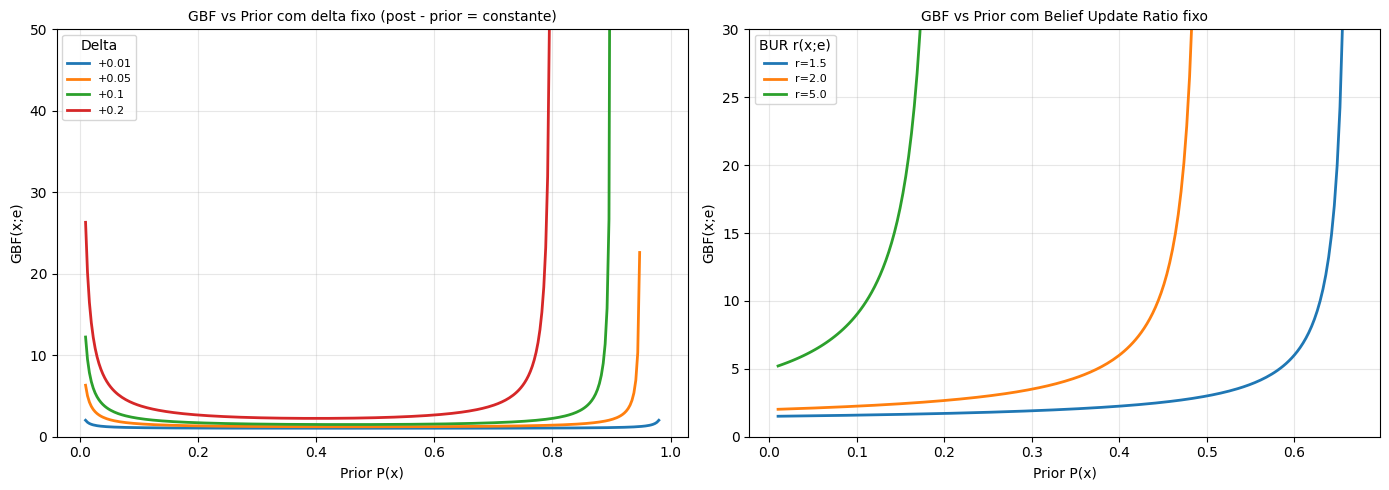

In [ ]:
priors_range = np.linspace(0.01, 0.98, 300)
deltas = [0.01, 0.05, 0.1, 0.2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for delta in deltas:
    gbfs = []
    for p in priors_range:
        post = p + delta
        if 0 < post < 1:
            gbfs.append(gbf(post, p))
        else:
            gbfs.append(np.nan)
    valid = [(p,g) for p,g in zip(priors_range,gbfs) if not np.isnan(g)]
    if valid:
        px,gx = zip(*valid)
        ax.plot(px, gx, lw=2, label=f'+{delta}')

ax.set_xlabel('Prior P(x)')
ax.set_ylabel('GBF(x;e)')
ax.set_title('GBF vs Prior com delta fixo (post - prior = constante)', fontsize=10)
ax.legend(title='Delta', fontsize=8)
ax.set_ylim(0, 50)
ax.grid(alpha=0.3)

ax2 = axes[1]
burs = [1.5, 2.0, 5.0]
for r in burs:
    gbfs = []
    for p in priors_range:
        post = r * p
        if 0 < post < 1:
            gbfs.append(gbf(post, p))
        else:
            gbfs.append(np.nan)
    valid = [(p,g) for p,g in zip(priors_range,gbfs) if not np.isnan(g)]
    if valid:
        px,gx = zip(*valid)
        ax2.plot(px, gx, lw=2, label=f'r={r}')

ax2.set_xlabel('Prior P(x)')
ax2.set_ylabel('GBF(x;e)')
ax2.set_title('GBF vs Prior com Belief Update Ratio fixo', fontsize=10)
ax2.legend(title='BUR r(x;e)', fontsize=8)
ax2.set_ylim(0, 30)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Sensibilidade aos extremos**: No primeiro caso, cada linha é um salto fixo na probabilidade. A linha vermelha é um salto de 20% (+0.2). Ela começa já no alto pois, como seu prior é 1%, um aumento de 20% resulta num GBF bem alto. Ao final, ela explodirá ao chegar no 0.8, o que é momento da probabilidade posterior já bater em 100%, o que é infinitamente relevante. As curvas verde e laranja seguem a mesma lógica, mas com um salto menor, necessitando que o prior chegue um pouco mais próximo de 1 para explodir. A azul fica comportada, pois aumentar 1% é irrelevante na maioria dos casos e só subiria próximo de 0.99. Todas elas estabilizam no meio do caminho, em priors medianos, pois quando as chances são 50/50 os aumentos não mudarão a compreensão deste cenário.

**Navalha de Ockham**: O segundo gráfico, chamado de Belief Update Ratio Fixo (BUR Fixo), mantém a força do salto proporcional. Para r=2, a probabilidade de um evento acontecer dobrou após a evidência. Este gráfico agora sempre cresce (monotônico). Se duas explicações têm o mesmo salto proporcional (r), o GBF dará maior nota ao que tiver o Prior mais alto, evitando escolher alternativas raras caso uma mais simples explicar igualmente bem (Navalha de Ockham).

### Corolários 1, 2 e 3

São filtros matemáricos que o MRE usa para decidir se uma explicação é boa ou não, sem o uso de cálculos complexos, garantindo que o MRE apresente explicações concisas e relevantes.

#### Corolários 1 e 2

O corolário 1 fala sobre a adição de uma variável $y$ fortalecer a explicação e o corolário 2 diz que adicionar $y$ enfraquece (superespecificação).

$$GBF(x, y; e) < GBF(x; e)$$

In [ ]:
explicacoes = [
    ("(notB, notC)",             {'B':'defective', 'C':'defective'}),
    ("(notB, notC, D=ok)",       {'B':'defective', 'C':'defective', 'D':'ok'}),
    ("(A=ok, notB, notC, D=ok)", {'A':'ok', 'B':'defective', 'C':'defective', 'D':'ok'})
]

print("--- Impacto da Adição de Variáveis ---")
for label, spec in explicacoes:
    score = gbf_joint(spec)
    print(f"GBF {label:<25} = {score:.4f}")

print("\n--- Análise de Relevância Local ---")
for g in ['A', 'D']:
    r_def = posts_circ[g] / PRIORS[g]
    r_ok  = (1 - posts_circ[g]) / (1 - PRIORS[g])
    print(f"Gate {g} | r({g}=defeituoso): {r_def:5.2f} | r({g}=ok): {r_ok:.4f}")

--- Impacto da Adição de Variáveis ---
GBF (notB, notC)              = 42.6152
GBF (notB, notC, D=ok)        = 39.9255
GBF (A=ok, notB, notC, D=ok)  = 39.5569

--- Análise de Relevância Local ---
Gate A | r(A=defeituoso): 24.42 | r(A=ok): 0.6191
Gate D | r(D=defeituoso):  3.01 | r(D=ok): 0.7765


Nossa base (notB, notC) gerou um GBF bem alto, que retrata uma explicação forte e focada.

Adicionar (D=ok) caiu o score, atrapalhou a relevância. O motivo está no valor de $r$ (Belief Update Ratio) de 0.777, que é a razão entre a probabilidade de D estar funcionando (0.699) e sua probabilidade inicial (0.9). A adição de uma variável que não ganha força com evidência, GBF é reduzido.

Adicionar ainda (A=ok) caiu mais ainda o score.

#### Corolário 3

Está diretamente ligado ao Explaining Away. Se a probabilidade de uma variável ser verdadeira diminui em relação à priori após considerarmos a evidência e o restante da explicação, ela não ajuda em nada e será excluída.

Se $P(y \mid x, e) < P(y \mid x)$, então $GBF(x, y; e) < GBF(x; e)$

Inputs:
- alvo_dict: variável $y$ a ser verificada
- condicao_dict: variável $x$ assumida

Processamento
- ev_circ: evidência observada no circuito é combinada com a nova condição $x$
- query: pega a probabilidade de $y$ ocorrer dado o critério

Output
- Probabilidade condicional

In [ ]:
def prob_condicional(alvo_dict, condicao_dict):
    evidencia_atualizada = {**ev_circ, **condicao_dict}
    alvos = list(alvo_dict.keys())
    q = infer_circuito.query(alvos, evidence=evidencia_atualizada, show_progress=False)
    return q.get_value(**alvo_dict)

In [ ]:
base = {'B': 'defective', 'C': 'defective'}

print("--- Teste do Corolário 3: A Variável 'Dilui' a Explicação? ---")

for gate, estado, prior in [('A', 'defective', PRIORS['A']),
                             ('D', 'ok', 1 - PRIORS['D'])]:

    p_cond = prob_condicional({gate: estado}, base)
    veredito = "MANTÉM (Sobe)" if p_cond > prior else "EXCLUI (Dilui)"
    print(f"Variável: {gate}={estado}")
    print(f"  > Prior: {prior:.4f} | Posterior Condicional: {p_cond:.4f}")
    print(f"  > Veredito: {veredito}\n")

--- Teste do Corolário 3: A Variável 'Dilui' a Explicação? ---
Variável: A=defective
  > Prior: 0.0160 | Posterior Condicional: 0.0165
  > Veredito: MANTÉM (Sobe)

Variável: D=ok
  > Prior: 0.9000 | Posterior Condicional: 0.8978
  > Veredito: EXCLUI (Dilui)



- A Defeituoso: A sua probabilidade marginal de ter defeito era alta (39.08%), mas ao saber que B e C falharam, a sua probabilidade cai (1.65%), o que é menor que o prior inicial de 1.6% — ou seja, saber que B e C falharam tornou A menos provável de ter falhado também. Isso é o Corolário 3: se P(y|x,e) < P(y|x), o GBF da explicação composta cai. O Explaining-Away é o fenômeno causal que causa isso — B e C já 'consomem' a explicação da corrente, sobrando menos para A.
- D Ok: O seu prior de funcionamento era 90% e após a explicação B + C caiu para 89,78%. Como a probabilidade resultante é inferior ao prior, torna-se inútil.

### CBF e Explaining Away

O **Conditional Bayes Factor (CBF)** mede o quanto uma nova variavel continua a ser importante após aceitarmos outra como verdadeira:

$$\text{CBF}(y; e \mid x) = \frac{P(e|y,x)}{P(e|\bar{y},x)} = \frac{P(y|e,x)(1-P(y|x))}{P(y|x)(1-P(y|e,x))}$$

O Teorema 3 mostra que CBF captura o explaining-away: quando uma causa já explica o efeito, o CBF das outras causas cai.

A Escala de Jeffreys mede a força de evidência em modelos estatísticos, especialmente na inferência Bayesiana, proposta pelo matemático Harold Jeffreys, dando significado qualitativo ao GBF (O quanto esses números provam que uma hipótese é superior a outra?).

O GBF não vê a probabilidade pura, mas sim o quanto os odds se alteram
- Probabilidade: chance de algo ocorrer
- Odds: comparativo entre a chance ocorrer e não ocorrer

$$\text{GBF} = \frac{\text{Odds Finais (Posterior)}}{\text{Odds Iniciais (Prior)}}$$

In [ ]:
jeffreys_data = [
    (0, 1, "Negativa"),#evidência aponta para hipótese contrária
    (1, 3, "Quase irrelevante"),#mudança muito pequena, não vale mencionar
    (3, 10, "Substancial"),#é uma evidência clara, não definitiva
    (10, 30, "Forte"),#prova robusta que explicação tem sentido
    (30, 100, "Muito forte"),#bem convincente
    (100, float('inf'), "Decisiva")#prova extrema, hipótese quase certa
]

In [ ]:
def forca_evidencia(valor):
    """Traduz o valor numérico para a escala qualitativa de Jeffreys."""
    for low, high, label in jeffreys_data:
        if low <= valor < high: return label
    return "Indefinida"

In [ ]:
base_bc = {'B': 'defective', 'C': 'defective'}
p_A_prior = PRIORS['A']
p_A_post_cond = prob_condicional({'A': 'defective'}, base_bc) # usando a função do passo anterior

cbf_A = gbf(p_A_post_cond, p_A_prior)

print("--- Duelo de Relevância: Explaining-Away ---")

gbf_A_isolado = gbf_joint({'A': 'defective'})
gbf_BC_isolado = gbf_joint({'B': 'defective', 'C': 'defective'})

resultados = [
    ("GBF(notB, notC) - Isolado", gbf_BC_isolado),
    ("GBF(notA)       - Isolado", gbf_A_isolado),
    ("CBF(notA | BC)  - Condicional", cbf_A)
]

for label, valor in resultados:
    print(f"{label:<30} | Valor: {valor:6.2f} | Força: {forca_evidencia(valor)}")

print(f"\nConclusão: O valor de {cbf_A:.2f} valida o paper (1.03).")

--- Duelo de Relevância: Explaining-Away ---
GBF(notB, notC) - Isolado      | Valor:  42.62 | Força: Muito forte
GBF(notA)       - Isolado      | Valor:  39.45 | Força: Muito forte
CBF(notA | BC)  - Condicional  | Valor:   1.03 | Força: Quase irrelevante

Conclusão: O valor de 1.03 valida o paper (1.03).


**GBF**: Ao analisarmos os portões A ou (B, C) separadamente, o GBF é alto. Ou seja, sem saber mais nada, qualquer um deles é um ótimo candidato para explicar a falha observada.

**CBF**: O Fator de Bayes Condicional mede o quanto uma variável adiciona de informação a algo que já sabemos. O valor 1.03 para notA | BC nos diz que, se já definimos que B e C falharam, a hipótese de A também ter falhado não ajuda em quase nada na explicação da evidência.

Essa é a competição de causas explicarem o efeito comum. N e C juntos já são bons em explicar a falha, tornando A redundante.

### K-MRE: Dominancia Forte e Fraca

O objetivo do K-MRE (Top-K Most Relevant Explanations) é encontrar as K melhores explicações. A dominância evita redundâncias aparecerem na lista.

A dominância forte retrata o seguinte: Se a explicação simples é tão boa quanto a complexa, a complexa é descartada.

A dominância fraca retrata outro lado: Só aceitaremos a entrada de mais variáveis (aumento da complexidade da explicação) se torná-la melhor que a anterior.

Dizer que o portão B falhou tem GBF de 42 e tentarmos incluir que o portão D tá funcionando, vai reduzir o GBF para 39. Como a mais curta é mais forte (ou mesmo se for igual), a longa é dominada e descartada.

Dizer que o portão B falhou e o C também, aumenta o GBF para 45, manterá a explicação. É mais complexa mas seu poder justifica.

A explicação é **Minimal** quando nenhuma domina ela.

In [ ]:
todas_explicacoes_circ = calcular_explicacoes_mre(
    infer_circuito, GATES, ev_circ, ESTADOS_CIRCUITO, PRIORS_CIRCUITO
)

todas_explicacoes_ordenadas = sorted(todas_explicacoes_circ, key=lambda x: -x['gbf'])

df_all = pd.DataFrame([
    {
        'Explicação': r['label'],
        'GBF': np.round(r['gbf'], 4)
    }
    for r in todas_explicacoes_ordenadas[:15]
])

display(df_all)

,Explicação,GBF
0,"B=defective, C=defective",42.6152
1,"A=ok, B=defective, C=defective",42.1547
2,"B=defective, C=defective, D=ok",39.9255
3,"A=ok, B=defective, C=defective, D=ok",39.5569
4,A=defective,39.4513
5,"A=defective, D=ok",37.0798
6,"A=defective, B=ok",36.9871
7,"A=defective, C=ok",35.9973
8,"B=defective, D=defective",35.8848
9,"A=ok, B=defective, D=defective",35.6706


notB, notC foi a combinação campeã. A, notB, notC tem GBF alto, mas foi eliminada.

In [ ]:
minimais = kmre(todas_explicacoes_circ, k=10)

print("--- K-MRE: Explicações MINIMAIS (Vencedoras) ---")
for r in minimais:
    forca = forca_evidencia(r['gbf'])
    print(f"GBF: {r['gbf']:6.2f} | {r['label']:<40} | Força: {forca}")

print("\n--- Por que as outras foram eliminadas? (Dominância Forte) ---")

casos = [
    ("(A=ok, B=defective, C=defective)", "(B=defective, C=defective)", "A é 'excesso de bagagem'"),
    ("(B=defective, C=defective, D=ok)", "(B=defective, C=defective)", "D=ok não ajuda em nada"),
    ("(A=defective, B=ok)",              "(A=defective)",              "B=ok dilui a força de A")
]

for removida, por, motivo in casos:
    print(f"Eliminada: {removida:<35} | Dominada por: {por:<28} | Motivo: {motivo}")

--- K-MRE: Explicações MINIMAIS (Vencedoras) ---
GBF:  42.62 | B=defective, C=defective                 | Força: Muito forte
GBF:  39.45 | A=defective                              | Força: Muito forte
GBF:  35.88 | B=defective, D=defective                 | Força: Muito forte

--- Por que as outras foram eliminadas? (Dominância Forte) ---
Eliminada: (A=ok, B=defective, C=defective)    | Dominada por: (B=defective, C=defective)   | Motivo: A é 'excesso de bagagem'
Eliminada: (B=defective, C=defective, D=ok)    | Dominada por: (B=defective, C=defective)   | Motivo: D=ok não ajuda em nada
Eliminada: (A=defective, B=ok)                 | Dominada por: (A=defective)                | Motivo: B=ok dilui a força de A


Cada uma dessas três vencedoras mostra uma linha de raciocínio imbatível em relevância.

## Estudos de Casos

O paper compara 3 metodos com metricas diferentes:
- **K-MRE**: score = GBF
- **K-MAP**: score = probabilidade posterior conjunta  
- **K-SIMP**: score = likelihood da evidencia dado a explicação

O K-MAP busca a maior probabilidade conjunta e o K-SIMP busca apenas Likelihood.


In [ ]:
explicaçoes_circ = calcular_explicacoes_mre(
    infer_circuito,
    GATES,
    ev_circ,
    ESTADOS_CIRCUITO,
    PRIORS_CIRCUITO
)

In [ ]:
mre_circ = kmre(explicaçoes_circ)

In [ ]:
configs_completas = [res for res in explicaçoes_circ if len(res['spec']) == len(GATES)]

k_map = sorted(configs_completas, key=lambda x: -x['p_post'])[:3]
top_6_para_simp = sorted(configs_completas, key=lambda x: -x['p_post'])[:6]

simp_cache = {}
p_input_current = cpd_Input.get_value(Input='current')

for res in top_6_para_simp:
    cfg_def = {k: v for k, v in res['spec'].items() if v == 'defective'}
    label_def = ", ".join([f"not{k}" for k in sorted(cfg_def.keys())]) or "(none)"

    if label_def not in simp_cache:
        ev_condicional = {'Input': ev_circ['Input'], **cfg_def}
        q_simp = infer_circuito.query(['TotalOutput'], evidence=ev_condicional, show_progress=False)

        p_total_output = q_simp.get_value(TotalOutput='current')
        simp_cache[label_def] = p_total_output * p_input_current

k_simp = sorted(simp_cache.items(), key=lambda x: -x[1])[:3]

print(f"{'Método':<10} {'Explicação':<45} {'Score':<10} {'Interpretação'}")
print("-" * 90)

for r in mre_circ:
    forca = forca_evidencia(r['gbf'])
    print(f"{'K-MRE':<10} {r['label']:<45} {r['gbf']:<10.4f} [{forca}]")

print()
for r in k_map:
    print(f"{'K-MAP':<10} {r['label']:<45} {r['p_post']:<10.4f} (Posterior)")

print()
for label, score in k_simp:
    print(f"{'K-SIMP':<10} {label:<45} {score:<10.4f} (Likelihood)")

Método     Explicação                                    Score      Interpretação
------------------------------------------------------------------------------------------
K-MRE      B=defective, C=defective                      42.6152    [Muito forte]
K-MRE      A=defective                                   39.4513    [Muito forte]
K-MRE      B=defective, D=defective                      35.8848    [Muito forte]

K-MAP      A=ok, B=defective, C=defective, D=ok          0.3475     (Posterior)
K-MAP      A=defective, B=ok, C=ok, D=ok                 0.2684     (Posterior)
K-MAP      A=ok, B=defective, C=ok, D=defective          0.2221     (Posterior)

K-SIMP     notB, notC, notD                              0.4950     (Likelihood)
K-SIMP     notB, notD                                    0.4909     (Likelihood)
K-SIMP     notB, notC                                    0.4841     (Likelihood)


### MRE vs. MAP na Rede da Viagem

In [ ]:
viagem_1 = DiscreteBayesianNetwork(
    [
        ('Saudável','Local'),
         ('Saudável','Vivo'),
          ('Local','Vivo')
          ]
    )

viagem_1.add_cpds(
    TabularCPD('Saudável',
               2,
               [[0.2], [0.8]],
               state_names={'Saudável': ['não', 'sim']}),

    TabularCPD('Local',
               2,
               [[0.8, 0.1],
                [0.2, 0.9]],
               evidence=['Saudável'],
               evidence_card=[2],
               state_names={'Local': ['casa', 'trilha'],
                            'Saudável': ['não', 'sim']}),

    TabularCPD('Vivo',
               2,
               [[0.10, 0.90, 0.01, 0.01],
                [0.90, 0.10, 0.99, 0.99]],
               evidence=['Saudável', 'Local'],
               evidence_card=[2, 2],
               state_names={'Vivo': ['não', 'sim'],
                            'Saudável': ['não', 'sim'],
                            'Local': ['casa', 'trilha']})
)

In [ ]:
N = 100
loc_states = ['casa'] + [f't{i+1}' for i in range(N)]
loc_vals = [[0.8, 0.1]] + [[(1-0.8)/N, (1-0.1)/N]] * N

alive_dead = [0.10] + [0.90] * N + [0.01] + [0.01] * N
alive_ok = [0.90] + [0.10] * N + [0.99] + [0.99] * N

vacation_100 = DiscreteBayesianNetwork(
    [
        ('Saudável','Local'),
        ('Saudável','Vivo'),
         ('Local','Vivo')
         ]
    )

vacation_100.add_cpds(
    TabularCPD('Saudável',
               2,
               [[0.2], [0.8]],
               state_names={'Saudável': ['não', 'sim']}),

    TabularCPD('Local',
               N+1,
               loc_vals,
               evidence=['Saudável'],
               evidence_card=[2],
               state_names={'Local': loc_states,
                            'Saudável': ['não', 'sim']}),

    TabularCPD('Vivo',
               2,
               [alive_dead, alive_ok],
               evidence=['Saudável', 'Local'],
               evidence_card=[2, N+1],
               state_names={'Vivo': ['não', 'sim'],
                            'Saudável': ['não', 'sim'],
                            'Local': loc_states})
)


In [ ]:
infer_viagem1 = VariableElimination(viagem_1)
infer_viagem100 = VariableElimination(vacation_100)

In [ ]:
ev_morto = {'Vivo': 'não'}
ALVO_V = ['Saudável', 'Local']

In [ ]:
ALVOS_V1 = ['Saudável', 'Local']
ESTADOS_V1 = {'Saudável': ['sim', 'não'], 'Local': ['casa', 'trilha']} # Ajuste 'casa' para o seu estado real
PRIORS_V1 = {
    'Saudável': {'não': 0.2, 'sim': 0.8},
    'Local': {'trilha': 0.2, 'casa': 0.8}
}

ALVOS_V100 = ['Saudável']
ESTADOS_V100 = {'Saudável': ['sim', 'não']}
PRIORS_V100 = {'Saudável': {'não': 0.2, 'sim': 0.8}}

In [ ]:
explicacoes_v1 = calcular_explicacoes_mre(infer_viagem1, ALVOS_V1, ev_morto, ESTADOS_V1, PRIORS_V1)
melhor_v1 = kmre(explicacoes_v1)[0] # Pega o Top 1 do cenário 1

infer_viagem100 = VariableElimination(vacation_100)
explicacoes_v100 = calcular_explicacoes_mre(infer_viagem100, ALVOS_V100, ev_morto, ESTADOS_V100, PRIORS_V100)
melhor_v100 = kmre(explicacoes_v100)[0] # Pega o Top 1 do cenário 100

map_v1 = infer_viagem1.map_query(ALVOS_V1, evidence=ev_morto, show_progress=False)
map_v100 = infer_viagem100.map_query(ALVOS_V100, evidence=ev_morto, show_progress=False)

print(f"{'Método':<10} {'1-Trilha (Explicativa)':<35} {'100-Trilhas (Diluída)':<30}")
print("-" * 85)

print(f"{'K-MRE':<10} {melhor_v1['label']:<35} {melhor_v100['label']:<30}")
print(f"{'Score':<10} GBF={melhor_v1['gbf']:<30.2f} GBF={melhor_v100['gbf']:<26.2f}")
print(f"{'Paper':<10} {'36.00':<35} {'26.00':<30}")

print("-" * 85)
str_map_v1 = ", ".join([f"{k}={v}" for k, v in sorted(map_v1.items())])
str_map_v100 = ", ".join([f"{k}={v}" for k, v in sorted(map_v100.items())])
print(f"{'K-MAP':<10} ({str_map_v1}){' ' * (33-len(str_map_v1))} ({str_map_v100})")

Método     1-Trilha (Explicativa)              100-Trilhas (Diluída)         
-------------------------------------------------------------------------------------
K-MRE      Local=trilha, Saudável=não          Saudável=não                  
Score      GBF=36.00                          GBF=26.00                     
Paper      36.00                               26.00                         
-------------------------------------------------------------------------------------
K-MAP      (Local=trilha, Saudável=não)        (Saudável=não)


O MRE é coerente, enquanto o MAP é instável.

O K-MRE no cenário de 100 trilhas encurtou a explicação somente para (não-saudável), enquanto o cenário com 1 trilha incluia o local. Este foi o efeito da diluição.
- 1 Trilha: trilha é um suspeito forte, pois há poucas alternativas.
- 100 trilhas: o local específico perde importância comparado ao fato dele não estar saudável.

O fato das repostas dos modelos terem sido iguais mostra coerência,

### Academe

A rede Academe modela o desempenho academico de um estudante. Dado que o aluno **reprovou** (FinalMark=fail), qual a melhor explicacao?

O objetivo aqui será testar variáveis multi-estado e avaliar a performance do MRE identificar apenas os fatores cruciais para o desempenho de um aluno.

Espera-se que o K-MRE apresente superioridade ao evitar ruídos do K-MAP. Este por sua vez tende a fornecer explicações excessivamente longas em redes com muitas variáveis conectadas.

In [ ]:
academia = DiscreteBayesianNetwork(
    [
        ('Teoria','NotaTP'),
        ('Prática','NotaTP'),
        ('NotaTP','NotaGlobal'),
        ('Extra','NotaGlobal'),
        ('NotaGlobal','NotaFinal'),
        ('OutrosFatores','NotaFinal'),
    ]
)

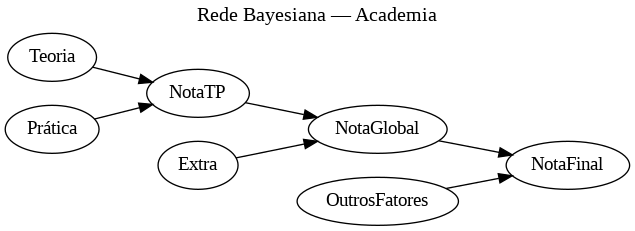

In [ ]:
G_academia = pgv.AGraph(directed=True)

G_academia.add_edges_from(academia.edges())

G_academia.node_attr['color'] = 'black'
G_academia.node_attr['fontcolor'] = 'black'
G_academia.node_attr['shape'] = 'ellipse'
G_academia.edge_attr['color'] = 'black'

G_academia.graph_attr['label'] = 'Rede Bayesiana — Academia'
G_academia.graph_attr['labelloc'] = 't'
G_academia.graph_attr['fontsize'] = '15'
G_academia.graph_attr['rankdir'] = 'LR'

G_academia.layout(prog='dot')
G_academia.draw('academia.png')

display(Image('academia.png'))

A arquitetura dessa rede é hierárquica e modela o desempenho escolar através de três níveis:
- Fatores de base: são os nós raíz. Incluem teoria, prática, extra e outros fatores.
- Intermediários: nota teórico-prática (NotaTP) combina teoria e prática, enquanto a NotaGlobal sintetiza o desempenho técnico com atividades extra.
- Resultado final: A NotaFinal é determinada ainda por outros fatores, como estado emocional ou imprevistos.

Um só resultado da nota final tem várias combinações de causas.

In [ ]:
NOTAS3 = ['boa','média','ruim']

academia.add_cpds(
    TabularCPD('Teoria',
               3,
               [[0.4],[0.3],[0.3]],
               state_names={'Teoria':NOTAS3}),

    TabularCPD('Prática',
               3,
               [[0.6],[0.25],[0.15]],
               state_names={'Prática':NOTAS3}),

    TabularCPD('Extra',
               2,
               [[0.3],[0.7]],
               state_names={'Extra':['sim','não']}),

    TabularCPD('OutrosFatores',
               2,
               [[0.8],[0.2]],
               state_names={'OutrosFatores':['mais','menos']}),

    TabularCPD('NotaTP',
               2,
               [[1.0, 0.85, 0.0, 0.90, 0.20, 0.0, 0.0, 0.0, 0.0],  # passa
                [0.0, 0.15, 1.0, 0.10, 0.80, 1.0, 1.0, 1.0, 1.0]], # reprova
               evidence=['Teoria','Prática'],
               evidence_card=[3,3],
               state_names={'NotaTP':['passa','reprova'],
                            'Teoria':NOTAS3,
                            'Prática':NOTAS3}),

    TabularCPD('NotaGlobal', 2,
               [[1.0, 1.0, 0.25, 0.0],  # passa
                [0.0, 0.0, 0.75, 1.0]], # reprova
               evidence=['NotaTP','Extra'],
               evidence_card=[2,2],
               state_names={'NotaGlobal':['passa','reprova'],
                            'NotaTP':['passa','reprova'],
                            'Extra':['sim','não']}),

    TabularCPD('NotaFinal', 2,
               [[1.0, 0.70, 0.05, 0.0],  # passa
                [0.0, 0.30, 0.95, 1.0]], # reprova
               evidence=['NotaGlobal','OutrosFatores'],
               evidence_card=[2,2],
               state_names={'NotaFinal':['passa','reprova'],
                            'NotaGlobal':['passa','reprova'],
                            'OutrosFatores':['mais','menos']})
)

assert academia.check_model()
print(f'  Evidência: NotaFinal = reprova')


  Evidência: NotaFinal = reprova


Nossa evidência será a falha do aluno e buscaremos encontrar qual a explicação mais objetiva disso ter ocorrido.

In [ ]:
infer_academia = VariableElimination(academia)

In [ ]:
alvos_academia = ['Teoria', 'Prática', 'Extra', 'OutrosFatores']

evidencia_academia = {'NotaFinal': 'reprova'}

estados_academia = {
    'Teoria': NOTAS3, 'Prática': NOTAS3,
    'Extra': ['sim','não'], 'OutrosFatores': ['mais','menos'],
}
priors_academia = {
    'Teoria':   {'boa':0.4,'média':0.3,'ruim':0.3},
    'Prática': {'boa':0.6,'média':0.25,'ruim':0.15},
    'Extra':    {'sim':0.3,'não':0.7},
    'OutrosFatores': {'mais':0.8,'menos':0.2},
}

In [ ]:
todas_explicacoes = calcular_explicacoes_mre(
    infer_academia,
    alvos_academia,
    evidencia_academia,
    estados_academia,
    priors_academia
)

mre_acad = kmre(todas_explicacoes)

map_acad_res = infer_academia.map_query(alvos_academia, evidence=evidencia_academia, show_progress=False)

print(f"{'Método':<10} {'Explicação Encontrada':<55} {'GBF / Score'}")
print("-" * 90)

for r in mre_acad:
    forca = forca_evidencia(r['gbf'])
    print(f"{'K-MRE':<10} {r['label']:<55} {r['gbf']:<10.2f} [{forca}]")

print("-" * 90)
label_map = ", ".join([f"{k}={v}" for k, v in sorted(map_acad_res.items())])
print(f"{'K-MAP':<10} {label_map:<55} (Config. Completa)")

print(f"\n{'REF PAPER':<10} MRE: (Teoria=ruim) ~3.02 | (Prática=ruim, Extra=não) ~2.30")

Método     Explicação Encontrada                                   GBF / Score
------------------------------------------------------------------------------------------
K-MRE      Teoria=ruim                                             3.02       [Substancial]
K-MRE      Extra=não, Prática=ruim                                 2.30       [Quase irrelevante]
K-MRE      Extra=não, OutrosFatores=menos, Prática=média, Teoria=média 1.83       [Quase irrelevante]
------------------------------------------------------------------------------------------
K-MAP      Extra=não, OutrosFatores=mais, Prática=boa, Teoria=ruim (Config. Completa)

REF PAPER  MRE: (Teoria=ruim) ~3.02 | (Prática=ruim, Extra=não) ~2.30


O valor de 3.02 diz que após observarmos que o aluno reprovou, nossa crença de que ele tem uma teoria ruim tornou-se 3 vezes mais forte do que antes. Na escala de Jeffreys, um valor em torno de 3 é substancial.

In [ ]:
dados_df = []

for res in todas_explicacoes:
    if len(res['spec']) == 1:
        var, estado = list(res['spec'].items())[0]

        dados_df.append({
            'Variavel': var,
            'Estado': estado,
            'P(estado|reprova)': np.round(res['p_post'], 4),
            'GBF': np.round(res['gbf'], 4),
            'Forca': forca_evidencia(res['gbf'])
        })

df_sing = pd.DataFrame(dados_df).sort_values('GBF', ascending=False)

display(df_sing)

,Variavel,Estado,P(estado|reprova),GBF,Forca
2,Teoria,ruim,0.5642,3.0205,Substancial
5,Prática,ruim,0.2821,2.2266,Quase irrelevante
9,OutrosFatores,menos,0.2623,1.4224,Quase irrelevante
7,Extra,não,0.7496,1.2828,Quase irrelevante
4,Prática,média,0.2947,1.2537,Quase irrelevante
1,Teoria,média,0.2537,0.7932,Negativa
6,Extra,sim,0.2504,0.7795,Negativa
8,OutrosFatores,mais,0.7377,0.7031,Negativa
3,Prática,boa,0.4232,0.4891,Negativa
0,Teoria,boa,0.1821,0.3340,Negativa


Embora seja muito provável que o aluno não faça atividades estras, este GBF é bem baixo. A maioria dos alunos já não faz atividades extras por padrão e o fato dele ter reprovado não mudou nossa crença sobre isso.

Para teoria=ruim, a evidência triplicou, sendo a causa que mais ganhou força com as evidências.

### Ásia K-MRE

Vamos retornar à nossa rede Ásia. O objetivo será encontrar o MRE para explicar a situação de um paciente e comparar com a versão do MAP.

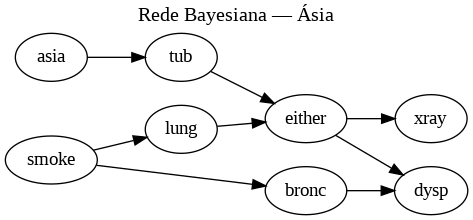

In [ ]:
Image('asia.png')

In [ ]:
priors_asia = {}
for d in DOENÇAS:
    q = infer.query([d], evidence={}, show_progress=False)
    sn = list(q.state_names[d])
    priors_asia[d] = q.values[sn.index('yes')]

print('Priors das doencas na rede Asia:')
for d,p in priors_asia.items():
    print(f'  P({d}=yes) = {p:.4f}')

ev_dysp = {'dysp':'yes'}
ev_xray = {'xray':'yes'}

Priors das doencas na rede Asia:
  P(tub=yes) = 0.0104
  P(lung=yes) = 0.0550
  P(bronc=yes) = 0.4500


In [ ]:
def run_kmre_asia(evidencia, nome_evidencia):
    ESTADOS_ASIA = {d: ['yes', 'no'] for d in DOENÇAS}
    PRIORS_ASIA_DICT = {d: {'yes': priors_asia[d], 'no': 1 - priors_asia[d]} for d in DOENÇAS}

    resultados = calcular_explicacoes_mre(
        infer, DOENÇAS, evidencia, ESTADOS_ASIA, PRIORS_ASIA_DICT
    )

    top_mre = kmre(resultados)

    print(f"--- Diagnóstico K-MRE: {nome_evidencia} ---")
    print(f"{'Explicação':<40} {'GBF':<10} {'Força (Jeffreys)'}")
    for r in top_mre:
        forca = forca_evidencia(r['gbf'])
        print(f"{r['label']:<40} {r['gbf']:<10.2f} [{forca}]")

    map_res = infer.map_query(DOENÇAS, evidence=evidencia, show_progress=False)
    print(f"K-MAP (Mais Provável): {map_res}\n")

run_kmre_asia({'dysp': 'yes'}, "Dispneia (Falta de Ar)")
run_kmre_asia({'xray': 'yes'}, "Raio-X Anormal")

--- Diagnóstico K-MRE: Dispneia (Falta de Ar) ---
Explicação                               GBF        Força (Jeffreys)
bronc=yes                                6.14       [Substancial]
K-MAP (Mais Provável): {'bronc': 'yes', 'lung': 'no', 'tub': 'no'}

--- Diagnóstico K-MRE: Raio-X Anormal ---
Explicação                               GBF        Força (Jeffreys)
lung=yes                                 16.42      [Forte]
K-MAP (Mais Provável): {'bronc': 'yes', 'lung': 'yes', 'tub': 'no'}



Dado dispneia, a bronquite ganha força 6.14 por ser uma causa comum e direta desse sintoma. K-MAP fornece a configuração comlpeta, juntamente com a bronquite.

Dado raio-x anormal, o câncer de pulmão dispara 16.42, pois na rde, um raio-xe alterado é um sinal muito mais específico para o câncer ou tuberculose do que para uma inflamação nos brônquios.

A bronquite causa falta de ar, mas não afeta o raio-x. O MAP incluiu pois simplesmente é provável que o paciente fume e logo tenha bronquite. O MRE removeu ela por ser uma informação que não ajuda a explicar a mancha no pulmão.

In [ ]:
ESTADOS_ASIA = {d: ['yes', 'no'] for d in DOENÇAS}
PRIORS_ASIA_DICT = {d: {'yes': priors_asia[d], 'no': 1 - priors_asia[d]} for d in DOENÇAS}

grupos = [
    (ev1, 'G1 — Fumante, xray+, dysp (Neisseria classico)'),
    (ev2, 'G2 — Asia, xray+, dysp (TB classico)'),
    (ev3, 'G3 — Fumante, dysp sem xray (ambiguo)'),
]

In [ ]:
for ev, nome in grupos:
    print(f"--- {nome} ---")

    explicaçoes_asia = calcular_explicacoes_mre(
        infer, DOENÇAS, ev, ESTADOS_ASIA, PRIORS_ASIA_DICT
    )

    mre_top = kmre(explicaçoes_asia)
    if mre_top:
        melhor = mre_top[0]
        print(f"  K-MRE (Melhor)  : ({melhor['label']})  GBF={melhor['gbf']:.4f}")

--- G1 — Fumante, xray+, dysp (Neisseria classico) ---
  K-MRE (Melhor)  : (lung=yes)  GBF=45.4212
--- G2 — Asia, xray+, dysp (TB classico) ---
  K-MRE (Melhor)  : (lung=no, tub=yes)  GBF=168.6396
--- G3 — Fumante, dysp sem xray (ambiguo) ---
  K-MRE (Melhor)  : (bronc=yes)  GBF=8.9769


Para o cenário 1 (fumante, raio-x+, dispneia), o K-MRE retornou lung=yes e bronc=yes como as melhores explicações separadas — coerente com a conjunta que mostrou 48% de coexistência. O K-MAP declarou as três doenças, incluindo tub=no desnecessariamente. Para o cenário 2 (Ásia, raio-x+, dispneia), tub=yes domina com GBF alto e o K-MRE o isola — o MAP ainda carrega lung=no e bronc=no sem acrescentar nada. Para o cenário 3 (fumante, dispneia), bronc=yes domina sozinho com GBF substancial, fechando o ciclo: o método que começamos a construir no Capítulo 1 agora entrega exatamente a explicação que os outros métodos não conseguiam.